In [9]:
import xarray as xr
import numpy as np

from scipy.interpolate import RegularGridInterpolator

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo
plt.style.use('/mnt/c/Ryan_Data/Tools/Python_Tool/ryan_mplstyle.mplstyle')

In [10]:
import scipy.io as sio

ds = sio.loadmat("../data/data_matlab/SQGp1MATLAB.mat")

In [11]:
ds

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Feb 25 21:25:43 2025',
 '__version__': '1.0',
 '__globals__': [],
 'cycloterm': array([[-0.04740199, -0.05624791, -0.06342359, ..., -0.02129708,
         -0.02962104, -0.03831807],
        [-0.04503982, -0.05436299, -0.06260461, ..., -0.01974059,
         -0.02732674, -0.03582298],
        [-0.0433977 , -0.05295775, -0.06166919, ..., -0.01691697,
         -0.0248744 , -0.0338429 ],
        ...,
        [-0.04584495, -0.05376233, -0.05620714, ...,  0.00354701,
         -0.01688736, -0.03336729],
        [-0.04953624, -0.05755137, -0.06146636, ..., -0.01104706,
         -0.02601175, -0.03880915],
        [-0.04942711, -0.05780001, -0.06345475, ..., -0.01901085,
         -0.02977174, -0.03987029]]),
 'k1_': array([[ 0.  ,  0.32,  0.64,  0.96,  1.28,  1.6 ,  1.92,  2.24,  2.56,
          2.88,  3.2 ,  3.52,  3.84,  4.16,  4.48,  4.8 ,  5.12,  5.44,
          5.76,  6.08,  6.4 ,  6.72,  7.04,  7.36,  7.68,  8.  ,  8.32

In [12]:
# Eta_ds = ds.Eta.values

f = 1
g = 1

In [13]:
dui_km = 1000

XC_2k = ds['px_'][0,:]
# YC_2k = (ds.YC[200:600].values)-8e5
YC_2k = ds['py_'][:,0]
XC_ui,YC_ui = np.meshgrid(XC_2k,YC_2k)
print(XC_2k.shape)

(512,)


In [14]:
# def interp_to_reggrid(input_data,x_loc,y_loc):
#     interp = RegularGridInterpolator(( x_loc, y_loc ), input_data.values.T  ,bounds_error=False, fill_value=None)
#     temp = interp((XC_ui,YC_ui))
#     return temp

In [15]:
# U_surface = ds.U[0,:,:]
# U_surface = interp_to_reggrid(U_surface,ds.XG, ds.YC-6e5)

# V_surface = ds.V[0,:,:]
# V_surface = interp_to_reggrid(V_surface,ds.XC, ds.YG-6e5)

In [16]:
# Uxdif = ds.U.differentiate("XG");  
# Uxdif = Uxdif.assign_coords(XG=ds.XC.values); Uxdif = Uxdif.rename({"XG":"XC"})
# Uxdif_surface = Uxdif[0,:,:]
# Uxdif_surface = interp_to_reggrid(Uxdif_surface,ds.XC, ds.YC-6e5)

# Vydif = ds.V.differentiate("YG");  
# Vydif = Vydif.assign_coords(YG=ds.YC.values); Vydif = Vydif.rename({"YG":"YC"})
# Vydif_surface = Vydif[0,:,:]
# Vydif_surface = interp_to_reggrid(Vydif_surface,ds.XC, ds.YC-6e5)

# Vxdif = ds.V.differentiate("XC");  
# Vxdif = Vxdif.assign_coords(XC=ds.XG.values); Vxdif = Vxdif.rename({"XC":"XG"})
# Vxdif_surface = Vxdif[0,:,:]
# Vxdif_surface = interp_to_reggrid(Vxdif_surface,ds.XG, ds.YG-6e5)

# Uydif = ds.U.differentiate("YC");  
# Uydif = Uydif.assign_coords(YC=ds.YG.values); Uydif = Uydif.rename({"YC":"YG"})
# Uydif_surface = Uydif[0,:,:]
# Uydif_surface = interp_to_reggrid(Uydif_surface,ds.XG, ds.YG-6e5)

In [17]:
# div_surface  = (Uxdif_surface+Vydif_surface)/np.abs(f)
# zeta_surface = (-Uydif_surface+Vxdif_surface)/f
# strain_surface = np.sqrt( (Uxdif_surface-Vydif_surface)**2+(Vxdif_surface+Uydif_surface)**2 )/np.abs(f)

# Eta = interp_to_reggrid(ds.Eta,ds.XC, ds.YC-6e5)

Eta = ds['ssh_full']

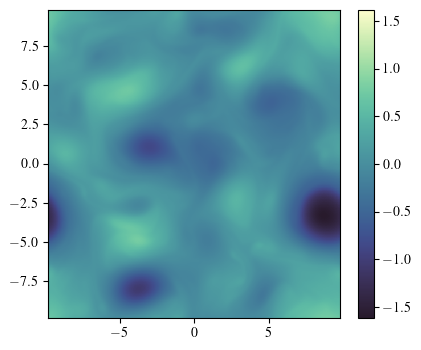

In [18]:
plt.figure(figsize=(16,4.0))

# plt.subplot(131)
# plt.pcolor(XC_ui/1e3,YC_ui/1e3,U_surface, cmap=cmo.balance, norm=colors.CenteredNorm())

# plt.colorbar()

# plt.subplot(132)
# plt.pcolor(XC_ui/1e3,YC_ui/1e3,V_surface, cmap=cmo.balance, norm=colors.CenteredNorm())
# plt.colorbar()

plt.subplot(133)
plt.pcolor(XC_ui,YC_ui,Eta, cmap=cmo.deep_r, norm=colors.CenteredNorm())
plt.colorbar()

In [19]:
# plt.figure(figsize=(16,4.0))

# plt.subplot(131)
# plt.pcolor(XC_ui/1e3,YC_ui/1e3,zeta_surface, cmap=cmo.balance, vmin=-2, vmax=2)

# plt.colorbar()

# plt.subplot(132)
# plt.pcolor(XC_ui/1e3,YC_ui/1e3,strain_surface, cmap=cmo.amp, vmin=0, vmax=2)
# plt.colorbar()

# plt.subplot(133)
# plt.pcolor(XC_ui/1e3,YC_ui/1e3,div_surface, cmap=cmo.balance, vmin=-1, vmax=1)
# plt.colorbar()

In [20]:
# zetat_all = zeta_surface
# # zetat_all = zrel
# straint_all = strain_surface

# print(zetat_all.shape)
# print(straint_all.shape)

# zmax = np.max(zetat_all[:,:].ravel())+1e-10
# zmin = np.min(zetat_all[:,:].ravel())

# z_range = np.linspace(zmin,zmax,30)
# s_range = np.arange(0,zmax,z_range[-1]-z_range[-2])

# fig=plt.figure(figsize=(3.5, 2.0))

# plt.hist2d(zetat_all.ravel(),straint_all.ravel(), density=True, bins=[z_range, s_range], cmap=cmo.amp, norm=colors.LogNorm())
# axs_max = max(abs(zetat_all.ravel()))
# plt.plot([0,axs_max],[0,axs_max],'--',color='k'); plt.plot([0,-axs_max],[0,axs_max],'--',color='k'); plt.axhline(0,color='k')
# plt.axis('equal'); 
# plt.xlim(min(zetat_all.ravel()),max(zetat_all.ravel()))
# plt.colorbar()
# plt.title('Vorticity-Strain JPDF')
# plt.xlabel("Vorticity ($\zeta^\mathrm{t}/f$)")
# plt.ylabel("Strain ($\sigma^\mathrm{t}/f$)")

# plt.show()

In [21]:
d_save = xr.Dataset(
    
    # dims=["x", "y"],
    coords=dict(
        x=(["x", "y"], XC_ui),
        y=(["x", "y"], YC_ui),
    ),
)

# d_save["U_surface"]=(["x", "y"],  U_surface)
# d_save["V_surface"]=(["x", "y"],  V_surface)
d_save["Eta"]=(["x", "y"],  Eta)
# d_save["zeta_surface"]=(["x", "y"],  zeta_surface)
# d_save["strain_surface"]=(["x", "y"],  strain_surface)
# d_save["div_surface"]=(["x", "y"],  div_surface)
d_save["f"]=(f)
d_save["g"]=(g)

In [22]:
d_save

<xarray.Dataset> Size: 6MB
Dimensions:  (x: 512, y: 512)
Coordinates:
    x        (x, y) float64 2MB -9.817 -9.779 -9.741 ... 9.702 9.741 9.779
    y        (x, y) float64 2MB -9.817 -9.817 -9.817 ... 9.779 9.779 9.779
Data variables:
    Eta      (x, y) float64 2MB 0.7079 0.7022 0.6964 ... 0.7322 0.7262 0.7202
    f        int64 8B 1
    g        int64 8B 1

In [24]:
d_save.to_netcdf('../data/data_matlab/processed/truth.nc')